# Bước 4: Train baseline CNN - Intel Image Classification





In [16]:
from pathlib import Path
import json
import random
import time
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None
    print("Seaborn chưa được cài đặt. Confusion matrix sẽ dùng matplotlib fallback.")

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


In [17]:
def set_seed(seed: int = 42) -> None:
    """Thiết lập seed để tăng khả năng tái lập kết quả."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Ti


In [18]:
CONFIG = {
    "model_name": "baseline_cnn",
    "image_size": 224,
    "batch_size": 32,
    "learning_rate": 1e-3,
    "num_epochs": 10,
    "num_workers": 0,
    "weight_decay": 1e-4,
    "dropout": 0.3,
    "random_seed": SEED,
    "early_stopping_patience": 3,
    "save_best_only": True,
}

print(json.dumps(CONFIG, indent=2, ensure_ascii=False))


{
  "model_name": "baseline_cnn",
  "image_size": 224,
  "batch_size": 32,
  "learning_rate": 0.001,
  "num_epochs": 10,
  "num_workers": 0,
  "weight_decay": 0.0001,
  "dropout": 0.3,
  "random_seed": 42,
  "early_stopping_patience": 3,
  "save_best_only": true
}


In [19]:
def find_project_root(start_path=None) -> Path:
    """Tìm project root dựa trên parent gần nhất có thư mục data/processed."""
    current = Path.cwd() if start_path is None else Path(start_path).resolve()
    candidates = [current, *current.parents]

    for candidate in candidates:
        if (candidate / "data" / "processed").exists():
            return candidate

    return current


def require_file(path: Path) -> Path:
    """Kiểm tra file bắt buộc tồn tại."""
    if not path.exists() or not path.is_file():
        raise FileNotFoundError(
            f"Không tìm thấy metadata bắt buộc: {path}\n"
            "Hãy chạy notebook notebooks/02b_export_splits_and_metadata.ipynb trước."
        )
    return path


PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"
REPORTS_DIR = PROJECT_ROOT / "reports"

metadata_paths = {
    "train_split": require_file(PROCESSED_DIR / "train_split.csv"),
    "val_split": require_file(PROCESSED_DIR / "val_split.csv"),
    "test_manifest": require_file(PROCESSED_DIR / "test_manifest.csv"),
    "class_to_idx": require_file(PROCESSED_DIR / "class_to_idx.json"),
    "idx_to_class": require_file(PROCESSED_DIR / "idx_to_class.json"),
}

train_df = pd.read_csv(metadata_paths["train_split"])
val_df = pd.read_csv(metadata_paths["val_split"])
test_df = pd.read_csv(metadata_paths["test_manifest"])

class_to_idx = json.loads(metadata_paths["class_to_idx"].read_text(encoding="utf-8"))
idx_to_class_raw = json.loads(metadata_paths["idx_to_class"].read_text(encoding="utf-8"))
idx_to_class = {int(idx): class_name for idx, class_name in idx_to_class_raw.items()}
class_names = [idx_to_class[idx] for idx in sorted(idx_to_class)]

print(f"Project root: {PROJECT_ROOT}")
print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Num classes: {len(class_names)}")
print("Class mapping:")
print(json.dumps(class_to_idx, indent=2, ensure_ascii=False))


Project root: d:\CITD\HK3\ML\intel-image-classification
Train samples: 11227
Val samples: 2807
Test samples: 3000
Num classes: 6
Class mapping:
{
  "buildings": 0,
  "forest": 1,
  "glacier": 2,
  "mountain": 3,
  "sea": 4,
  "street": 5
}


## Transform cho baseline

Train dùng resize, augmentation nhẹ, chuyển tensor và normalize. Validation/test chỉ resize, chuyển tensor và normalize.

Normalize dùng mean/std ImageNet để thuận tiện khi chuyển sang pretrained models như ResNet hoặc MobileNet ở các thử nghiệm sau.


In [20]:
def get_transforms(image_size: int):
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]

    train_transform = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ToTensor(),
            transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
        ]
    )

    eval_transform = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
        ]
    )

    return train_transform, eval_transform


train_transform, eval_transform = get_transforms(CONFIG["image_size"])

print("Train transform:")
print(train_transform)
print("\nEval transform:")
print(eval_transform)


Train transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Eval transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [21]:
class IntelImageDataset(Dataset):
    """Dataset đọc ảnh từ metadata đã export."""

    def __init__(self, dataframe: pd.DataFrame, project_root: Path, transform=None, return_path: bool = False):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.project_root = Path(project_root)
        self.transform = transform
        self.return_path = return_path

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, index: int):
        row = self.dataframe.iloc[index]
        image_path = Path(row["image_path"])
        if not image_path.is_absolute():
            image_path = self.project_root / image_path

        label = int(row["label"])

        with Image.open(image_path) as image:
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        if self.return_path:
            return image, label, str(image_path)

        return image, label


In [22]:
train_dataset = IntelImageDataset(train_df, PROJECT_ROOT, transform=train_transform)
val_dataset = IntelImageDataset(val_df, PROJECT_ROOT, transform=eval_transform)
test_dataset = IntelImageDataset(test_df, PROJECT_ROOT, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=(DEVICE.type == "cuda"),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=(DEVICE.type == "cuda"),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=(DEVICE.type == "cuda"),
)

print(f"train_dataset: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"val_dataset: {len(val_dataset)} samples, {len(val_loader)} batches")
print(f"test_dataset: {len(test_dataset)} samples, {len(test_loader)} batches")


train_dataset: 11227 samples, 351 batches
val_dataset: 2807 samples, 88 batches
test_dataset: 3000 samples, 94 batches


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64
Batch device before training step: cpu


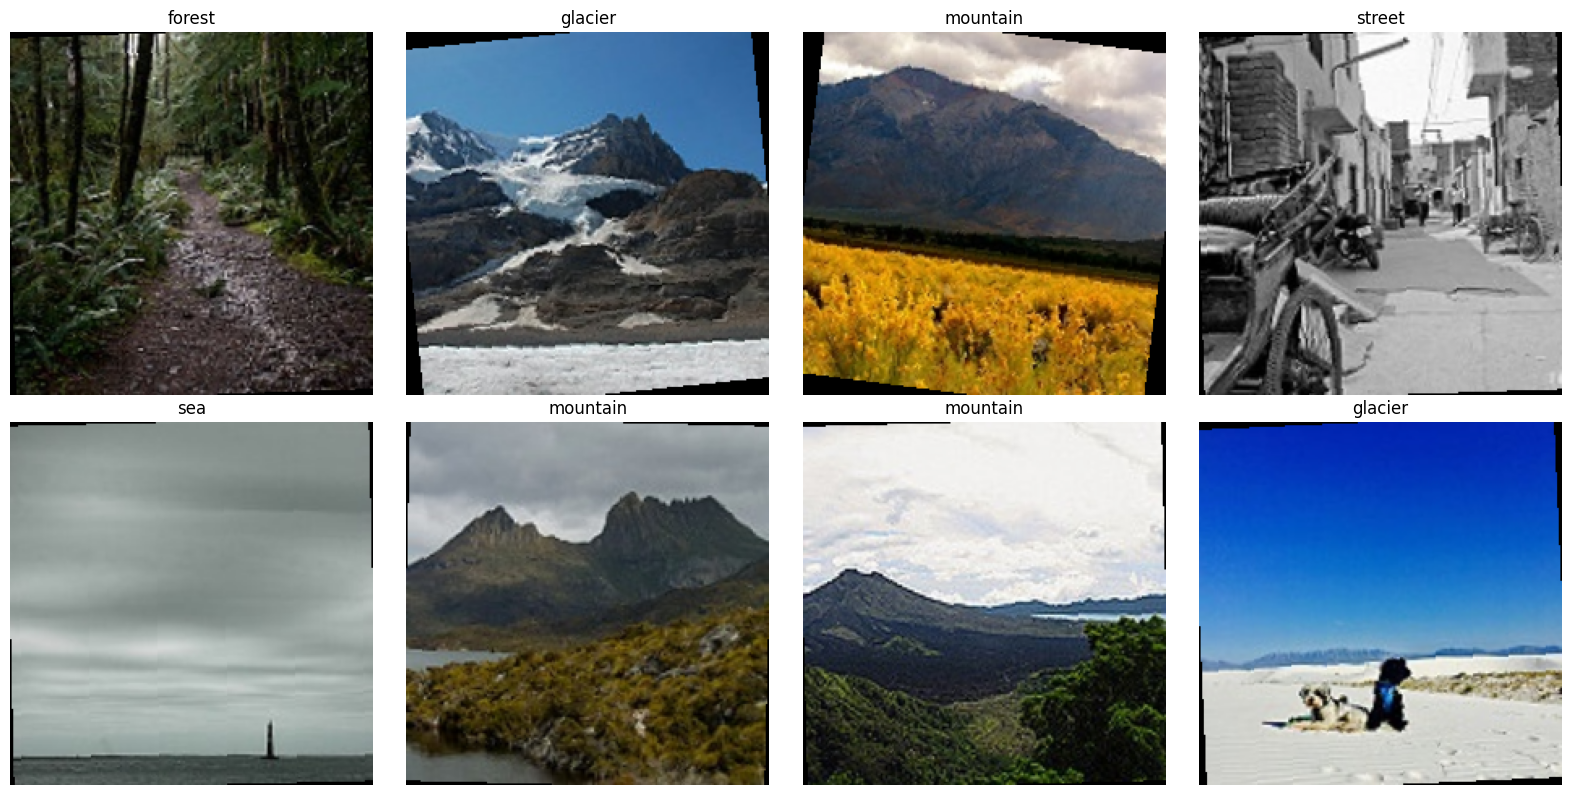

In [23]:
def unnormalize_image(image_tensor: torch.Tensor) -> np.ndarray:
    """Đảo normalize ImageNet để hiển thị ảnh."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = image_tensor.detach().cpu() * std + mean
    image = image.clamp(0, 1)
    return image.permute(1, 2, 0).numpy()


def show_image_batch(images: torch.Tensor, labels: torch.Tensor, idx_to_class: dict[int, str], max_images: int = 8) -> None:
    n_images = min(max_images, images.shape[0])
    n_cols = 4
    n_rows = int(np.ceil(n_images / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for idx, ax in enumerate(axes):
        ax.axis("off")
        if idx >= n_images:
            continue

        image = unnormalize_image(images[idx])
        label = int(labels[idx].item())
        ax.imshow(image)
        ax.set_title(idx_to_class[label])

    plt.tight_layout()
    plt.show()


sample_images, sample_labels = next(iter(train_loader))
print(f"Image batch shape: {sample_images.shape}")
print(f"Label batch shape: {sample_labels.shape}")
print(f"Image dtype: {sample_images.dtype}")
print(f"Label dtype: {sample_labels.dtype}")
print(f"Batch device before training step: {sample_images.device}")

show_image_batch(sample_images, sample_labels, idx_to_class, max_images=8)


## Phần model dễ thay thế

Để thử model mới, ưu tiên chỉ đổi `CONFIG["model_name"]` và mở rộng `build_model(...)`. Toàn bộ DataLoader, training loop, evaluation, plotting và checkpointing giữ nguyên.


In [24]:
class BaselineCNN(nn.Module):
    """CNN baseline nhỏ, dùng làm mốc so sánh ban đầu."""

    def __init__(self, num_classes: int, dropout: float = 0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [25]:
def build_model(model_name: str, num_classes: int, config: dict) -> nn.Module:
    """Model factory. Teammate chỉ cần mở rộng hàm này khi thêm model mới."""
    model_name = model_name.lower()

    if model_name == "baseline_cnn":
        return BaselineCNN(num_classes=num_classes, dropout=config["dropout"])

    # Gợi ý mở rộng sau:
    # if model_name == "resnet18":
    #     ...
    # if model_name == "mobilenetv2":
    #     ...

    raise NotImplementedError(f"Model chưa được implement: {model_name}")


In [26]:
def count_trainable_parameters(model: nn.Module) -> int:
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


num_classes = len(class_names)
model = build_model(CONFIG["model_name"], num_classes=num_classes, config=CONFIG)
model = model.to(DEVICE)

print(model)
print(f"Trainable parameters: {count_trainable_parameters(model):,}")


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1):

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1,
)

print(optimizer)
print("Scheduler: ReduceLROnPlateau(mode='min', factor=0.5, patience=1)")


Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: ReduceLROnPlateau(mode='min', factor=0.5, patience=1)


In [28]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Train một epoch và trả về loss/accuracy."""
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * batch_size
        running_correct += (preds == labels).sum().item()
        total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples
    return epoch_loss, epoch_acc


In [29]:
def evaluate_one_epoch(model, dataloader, criterion, device):
    """Evaluate một epoch, dùng lại cho validation và test."""
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            running_correct += (preds == labels).sum().item()
            total_samples += batch_size

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples
    return epoch_loss, epoch_acc, all_labels, all_preds


In [30]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

model_name = CONFIG["model_name"]
checkpoint_path = MODELS_DIR / f"{model_name}_best.pth"
history_path = REPORTS_DIR / f"{model_name}_history.csv"

history = []
best_val_acc = 0.0
best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0
best_model_state = copy.deepcopy(model.state_dict())
start_time = time.time()

for epoch in range(1, CONFIG["num_epochs"] + 1):
    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = evaluate_one_epoch(model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "learning_rate": current_lr,
        }
    )

    improved = val_acc > best_val_acc
    if improved:
        best_val_acc = val_acc
        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            {
                "epoch": epoch,
                "model_name": model_name,
                "model_state_dict": best_model_state,
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_acc": best_val_acc,
                "best_val_loss": best_val_loss,
                "config": CONFIG,
                "class_to_idx": class_to_idx,
                "idx_to_class": idx_to_class_raw,
            },
            checkpoint_path,
        )
    else:
        epochs_without_improvement += 1

    epoch_time = time.time() - epoch_start
    print(
        f"Epoch {epoch:02d}/{CONFIG['num_epochs']} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | "
        f"best_val_acc={best_val_acc:.4f} | "
        f"lr={current_lr:.2e} | "
        f"time={epoch_time:.1f}s"
    )

    if epochs_without_improvement >= CONFIG["early_stopping_patience"]:
        print(f"Early stopping tại epoch {epoch}. Best epoch: {best_epoch}.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(history_path, index=False)

total_time = time.time() - start_time
print(f"Training finished in {total_time / 60:.2f} minutes.")
print(f"Best checkpoint: {checkpoint_path}")
print(f"History saved: {history_path}")


Epoch 01/10 | train_loss=1.0401, train_acc=0.5782 | val_loss=0.8653, val_acc=0.6530 | best_val_acc=0.6530 | lr=1.00e-03 | time=34.7s


KeyboardInterrupt: 

In [ ]:
learning_curve_path = FIGURES_DIR / f"{CONFIG['model_name']}_learning_curves.png"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val loss")
axes[0].set_title("Loss curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train acc")
axes[1].plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Val acc")
axes[1].set_title("Accuracy curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(learning_curve_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved learning curves: {learning_curve_path}")


In [ ]:
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Không tìm thấy checkpoint: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)

print(f"Loaded best checkpoint from epoch {checkpoint['epoch']}")
print(f"Best val accuracy: {checkpoint['best_val_acc']:.4f}")


In [ ]:
test_loss, test_acc, test_labels, test_preds = evaluate_one_epoch(model, test_loader, criterion, DEVICE)

precision, recall, f1, _ = precision_recall_fscore_support(
    test_labels,
    test_preds,
    average="weighted",
    zero_division=0,
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Weighted precision: {precision:.4f}")
print(f"Weighted recall: {recall:.4f}")
print(f"Weighted F1: {f1:.4f}")
print(f"Sklearn accuracy check: {accuracy_score(test_labels, test_preds):.4f}")


In [ ]:
report_dict = classification_report(
    test_labels,
    test_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).transpose()
report_path = REPORTS_DIR / f"{CONFIG['model_name']}_classification_report.csv"
report_df.to_csv(report_path)

display(report_df)
print("\nClassification report:")
print(
    classification_report(
        test_labels,
        test_preds,
        target_names=class_names,
        zero_division=0,
    )
)
print(f"Saved classification report: {report_path}")


In [ ]:
cm = confusion_matrix(test_labels, test_preds, labels=list(range(num_classes)))
confusion_matrix_path = FIGURES_DIR / f"{CONFIG['model_name']}_confusion_matrix.png"

plt.figure(figsize=(10, 8))
if sns is not None:
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
else:
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.colorbar()
    plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
    plt.yticks(range(num_classes), class_names)
    for row_idx in range(num_classes):
        for col_idx in range(num_classes):
            plt.text(col_idx, row_idx, cm[row_idx, col_idx], ha="center", va="center")

plt.title("Confusion matrix - Test set")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig(confusion_matrix_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved confusion matrix: {confusion_matrix_path}")


In [ ]:
summary = {
    "model_name": CONFIG["model_name"],
    "best_epoch": int(checkpoint["epoch"]),
    "best_val_accuracy": float(checkpoint["best_val_acc"]),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "weighted_precision": float(precision),
    "weighted_recall": float(recall),
    "weighted_f1": float(f1),
    "epochs_trained": int(len(history_df)),
    "checkpoint_path": str(checkpoint_path),
    "history_path": str(history_path),
    "classification_report_path": str(report_path),
    "learning_curve_path": str(learning_curve_path),
    "confusion_matrix_path": str(confusion_matrix_path),
}

summary_path = REPORTS_DIR / f"{CONFIG['model_name']}_test_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

print("Tổng hợp kết quả cuối notebook:")
for key, value in summary.items():
    print(f"- {key}: {value}")
print(f"- summary_path: {summary_path}")
